In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from simulator_fast import simulate_fast
import time

In [8]:
# Load observed data from the 'data' directory
obs_infected = pd.read_csv('data/infected_timeseries.csv')
obs_rewiring = pd.read_csv('data/rewiring_timeseries.csv')
obs_degrees = pd.read_csv('data/final_degree_histograms.csv')

In [9]:
peaks_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].max()
rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].sum()

N_agents = 200
obs_degrees['deg_x_count'] = obs_degrees['degree'] * obs_degrees['count']
obs_degrees['deg2_x_count'] = (obs_degrees['degree']**2) * obs_degrees['count']
mean_deg_per_rep = obs_degrees.groupby('replicate_id')['deg_x_count'].sum() / N_agents
var_deg_per_rep = obs_degrees.groupby('replicate_id')['deg2_x_count'].sum() / N_agents - mean_deg_per_rep**2

idx_max_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].idxmax()
time_to_peak_per_rep = obs_infected.loc[idx_max_per_rep, 'time']

target_peak = peaks_per_rep.mean()
std_peak = peaks_per_rep.std()

target_rewires = rewires_per_rep.mean()
std_rewires = rewires_per_rep.std()

target_var_deg = var_deg_per_rep.mean()
std_var_deg = var_deg_per_rep.std()

target_time = time_to_peak_per_rep.mean()
std_time = time_to_peak_per_rep.std()

print("=== Targets & Normalization Weights (Std) ===")
print(f"Peak Infected : Mean = {target_peak:.3f}, Std = {std_peak:.3f}")
print(f"Total Rewires : Mean = {target_rewires:.1f}, Std = {std_rewires:.1f}")
print(f"Degree Variance: Mean = {target_var_deg:.2f}, Std = {std_var_deg:.2f}")
print(f"Time to Peak  : Mean = {target_time:.1f}, Std = {std_time:.1f}")

=== Targets & Normalization Weights (Std) ===
Peak Infected : Mean = 0.657, Std = 0.043
Total Rewires : Mean = 545.1, Std = 38.6
Degree Variance: Mean = 10.34, Std = 1.24
Time to Peak  : Mean = 8.8, Std = 1.2


In [ ]:
N_particles = 100_000
tolerance = 4.0 

accepted_params = []
np.random.seed(100)
degrees_arr = np.arange(31)

print("Starting Fast ABC with time_to_peak...")
start_time = time.time()

# For compiler optimization, we can run a dummy simulation before the loop
_ = simulate_fast(0.1, 0.1, 0.1)

for i in range(N_particles):
    beta = np.random.uniform(0.05, 0.50)
    gamma = np.random.uniform(0.02, 0.20)
    rho = np.random.uniform(0.0, 0.8)
    
    sim_infected, sim_rewires, sim_degrees = simulate_fast(beta=beta, gamma=gamma, rho=rho)
    
    # summary statistics
    sim_peak = np.max(sim_infected)
    sim_rewires_tot = np.sum(sim_rewires)
    sim_mean_deg = np.sum(degrees_arr * sim_degrees) / 200
    sim_var_deg = np.sum((degrees_arr**2) * sim_degrees) / 200 - sim_mean_deg**2
    
    # new summary statistic: time to peak
    sim_time_to_peak = np.argmax(sim_infected)
    
    norm_diff_peak = (sim_peak - target_peak) / std_peak
    norm_diff_rewires = (sim_rewires_tot - target_rewires) / std_rewires
    norm_diff_deg = (sim_var_deg - target_var_deg) / std_var_deg
    norm_diff_time = (sim_time_to_peak - target_time) / std_time
    
    # the euclidean distance in the normalized summary statistic space
    distance = np.sqrt(norm_diff_peak**2 + norm_diff_rewires**2 + norm_diff_deg**2 + norm_diff_time**2)
    
    if distance < tolerance:
        accepted_params.append({'beta': beta, 'gamma': gamma, 'rho': rho})

end_time = time.time()
print(f"Total accepted particles: {len(accepted_params)}")
print(f"Execution time: {end_time - start_time:.2f} seconds")

Starting Fast ABC with time_to_peak...
Total accepted particles: 5343
Execution time: 177.37 seconds



Total accepted particles: 5343


,beta,gamma,rho
0,0.309606,0.153646,0.504147
1,0.275160,0.148893,0.420765
2,0.231296,0.083774,0.400491
3,0.194599,0.057477,0.361007
4,0.318305,0.097612,0.473918


Saved histograms to: plots/posterior_histograms_s4_time.pdf


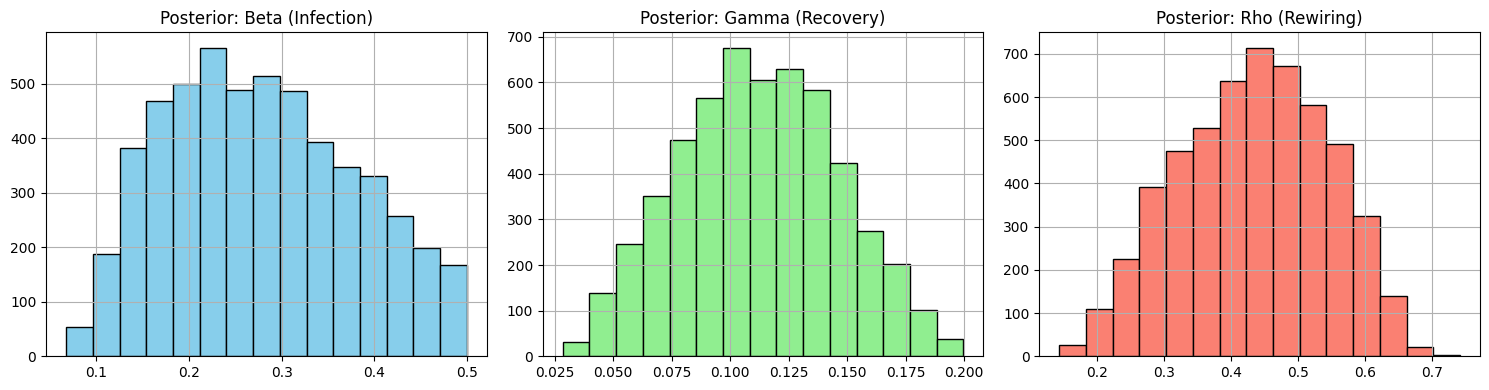

Generating Pairwise Plots...
Saved pairplot to: plots/posterior_pairplot_s4_time.pdf


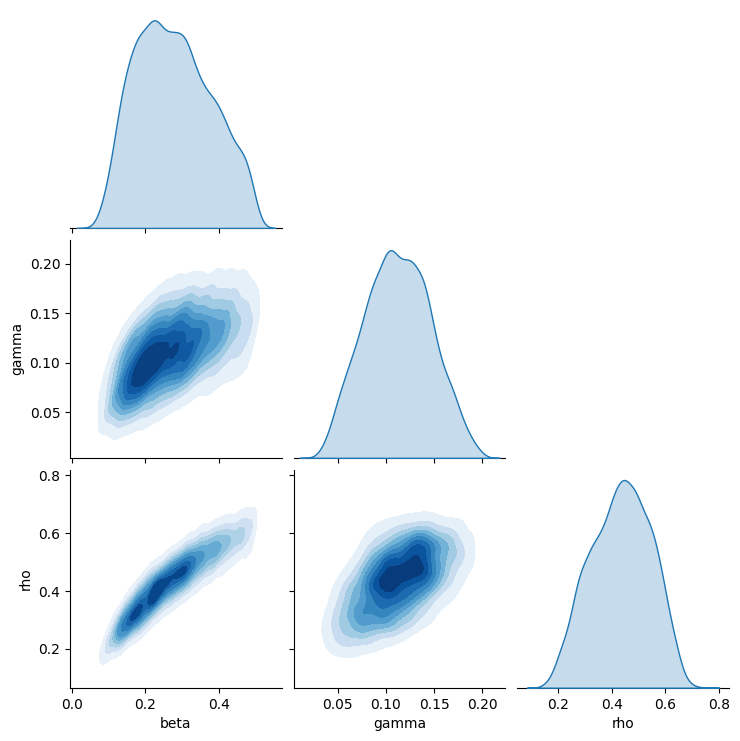

In [11]:
# ---------------------------------------------------------
# Check and create the directory for saving plots
# ---------------------------------------------------------
if not os.path.exists('plots'):
    os.makedirs('plots')

df_posterior = pd.DataFrame(accepted_params)
print(f"\nTotal accepted particles: {len(df_posterior)}")

if len(df_posterior) > 0:
    display(df_posterior.head())
    
    # ---------------------------------------------------------
    # 1. Marginal Histograms 
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    df_posterior['beta'].hist(ax=axes[0], bins=15, color='skyblue', edgecolor='black')
    axes[0].set_title('Posterior: Beta (Infection)')
    
    df_posterior['gamma'].hist(ax=axes[1], bins=15, color='lightgreen', edgecolor='black')
    axes[1].set_title('Posterior: Gamma (Recovery)')
    
    df_posterior['rho'].hist(ax=axes[2], bins=15, color='salmon', edgecolor='black')
    axes[2].set_title('Posterior: Rho (Rewiring)')
    
    plt.tight_layout()
    
    # Change the filename to prevent overwriting previous results
    hist_path = 'plots/posterior_histograms_s4_time.pdf'
    plt.savefig(hist_path, format='pdf', bbox_inches='tight')
    print(f"Saved histograms to: {hist_path}")
    
    plt.show()
    
    # ---------------------------------------------------------
    # 2. Pairwise plots
    # ---------------------------------------------------------
    print("Generating Pairwise Plots...")
    g = sns.pairplot(df_posterior, kind='kde', corner=True, 
                    plot_kws={'fill': True, 'cmap': 'Blues'}) 
    
    # Change the filename to prevent overwriting previous results
    pairplot_path = 'plots/posterior_pairplot_s4_time.pdf'
    g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
    print(f"Saved pairplot to: {pairplot_path}")
    
    plt.show()
    
else:
    print("No particles accepted. Try increasing 'tolerance'.")